## Imports

In [30]:
import numpy as np
import pandas as pd
import sys
sys.path.append("../src")
from utils import get_target_data

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier
from utils import cross_validate_target

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform



## Load Processed Data

In [31]:
X = np.load("../data/processed/X_morgan.npy")
y = np.load("../data/processed/y_targets.npy")

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (7831, 2048)
y shape: (7831, 12)


## Test Data Preparation on NR-AR

In [32]:
targets = ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 
           'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 
           'SR-HSE', 'SR-MMP', 'SR-p53']

X_train, X_test, y_train, y_test, class_weights = get_target_data(X, y, target_idx=0)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train positive rate: {y_train.mean()*100:.1f}%")
print(f"y_test positive rate:  {y_test.mean()*100:.1f}%")
print(f"Class weights: {class_weights}")

X_train: (5812, 2048)
X_test:  (1453, 2048)
y_train positive rate: 4.2%
y_test positive rate:  4.3%
Class weights: {0: np.float64(0.5221922731356694), 1: np.float64(11.765182186234817)}


## Define Targets and Models


In [33]:
targets = ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 
           'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 
           'SR-HSE', 'SR-MMP', 'SR-p53']

models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    "XGBoost":       XGBClassifier(n_estimators=200, eval_metric='auc', random_state=42, verbosity=0),
    "Logistic Reg":  LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
}



## Cross-Validation Model Functions

In [34]:
def rf_fn(cw_dict, y_train):
    return RandomForestClassifier(n_estimators=200, class_weight=cw_dict, random_state=42, n_jobs=-1)

def lr_fn(cw_dict, y_train):
    return LogisticRegression(class_weight=cw_dict, max_iter=1000, random_state=42)

def xgb_fn(cw_dict, y_train):
    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    return XGBClassifier(n_estimators=200, scale_pos_weight=neg/pos, eval_metric='auc', random_state=42, verbosity=0)

print("Model functions defined!")

Model functions defined!


## Baseline Comparison (single 80/20 split — kept for reference only)

*Note: these scores come from one train/test split and can vary by chance. The Cross-Validation section below is the trustworthy evaluation used for model selection.*

In [35]:
results = []

for i, target in enumerate(targets):
    print(f"Training on {target}...")
    
    X_train, X_test, y_train, y_test, class_weights = get_target_data(X, y, target_idx=i)
    
    for model_name, model in models.items():
        # Handle XGBoost class weight differently
        if model_name == "XGBoost":
            neg = (y_train == 0).sum()
            pos = (y_train == 1).sum()
            model.set_params(scale_pos_weight=neg/pos)
        
        model.fit(X_train, y_train)
        proba = model.predict_proba(X_test)[:, 1]
        
        results.append({
            "Target":    target,
            "Model":     model_name,
            "ROC-AUC":   round(roc_auc_score(y_test, proba), 3),
            "PR-AUC":    round(average_precision_score(y_test, proba), 3),
        })

print("\nAll done!")

Training on NR-AR...
Training on NR-AR-LBD...
Training on NR-AhR...
Training on NR-Aromatase...
Training on NR-ER...
Training on NR-ER-LBD...


KeyboardInterrupt: 

## Cross-Validation Results (5-Fold Stratified) — primary evaluation

In [ ]:
cv_results = []

model_fns = {
    "Random Forest": rf_fn,
    "XGBoost": xgb_fn,
    "Logistic Reg": lr_fn,
}

for i, target in enumerate(targets):
    print(f"CV on {target}...")
    for model_name, fn in model_fns.items():
        res = cross_validate_target(X, y, target_idx=i, model_fn=fn, n_splits=5)
        cv_results.append({
            "Target": target,
            "Model": model_name,
            "ROC-AUC mean": round(res["roc_auc_mean"], 3),
            "ROC-AUC std":  round(res["roc_auc_std"], 3),
            "PR-AUC mean":  round(res["pr_auc_mean"], 3),
            "PR-AUC std":   round(res["pr_auc_std"], 3),
            "Accuracy mean": round(res["accuracy_mean"], 3),
            "Confusion Matrix": res["confusion_matrix"],
        })

print("\nAll CV done!")

CV on NR-AR...
CV on NR-AR-LBD...
CV on NR-AhR...
CV on NR-Aromatase...
CV on NR-ER...
CV on NR-ER-LBD...
CV on NR-PPAR-gamma...
CV on SR-ARE...
CV on SR-ATAD5...
CV on SR-HSE...
CV on SR-MMP...
CV on SR-p53...

All CV done!


## View CV Results Table

In [ ]:
df_cv = pd.DataFrame(cv_results)
print(df_cv[["Target", "Model", "ROC-AUC mean", "ROC-AUC std", "PR-AUC mean", "PR-AUC std"]])

           Target          Model  ROC-AUC mean  ROC-AUC std  PR-AUC mean  \
0           NR-AR  Random Forest         0.786        0.028        0.524   
1           NR-AR        XGBoost         0.765        0.030        0.510   
2           NR-AR   Logistic Reg         0.771        0.029        0.495   
3       NR-AR-LBD  Random Forest         0.849        0.010        0.637   
4       NR-AR-LBD        XGBoost         0.849        0.023        0.608   
5       NR-AR-LBD   Logistic Reg         0.856        0.014        0.593   
6          NR-AhR  Random Forest         0.890        0.014        0.608   
7          NR-AhR        XGBoost         0.872        0.014        0.600   
8          NR-AhR   Logistic Reg         0.859        0.012        0.549   
9    NR-Aromatase  Random Forest         0.821        0.030        0.409   
10   NR-Aromatase        XGBoost         0.778        0.045        0.393   
11   NR-Aromatase   Logistic Reg         0.778        0.041        0.336   
12          

## Save CV Results

In [ ]:
df_cv.to_csv("../reports/cv_results.csv", index=False)
print("CV results saved!")

CV results saved!


## CV ROC-AUC Heatmap (mean across 5 folds)

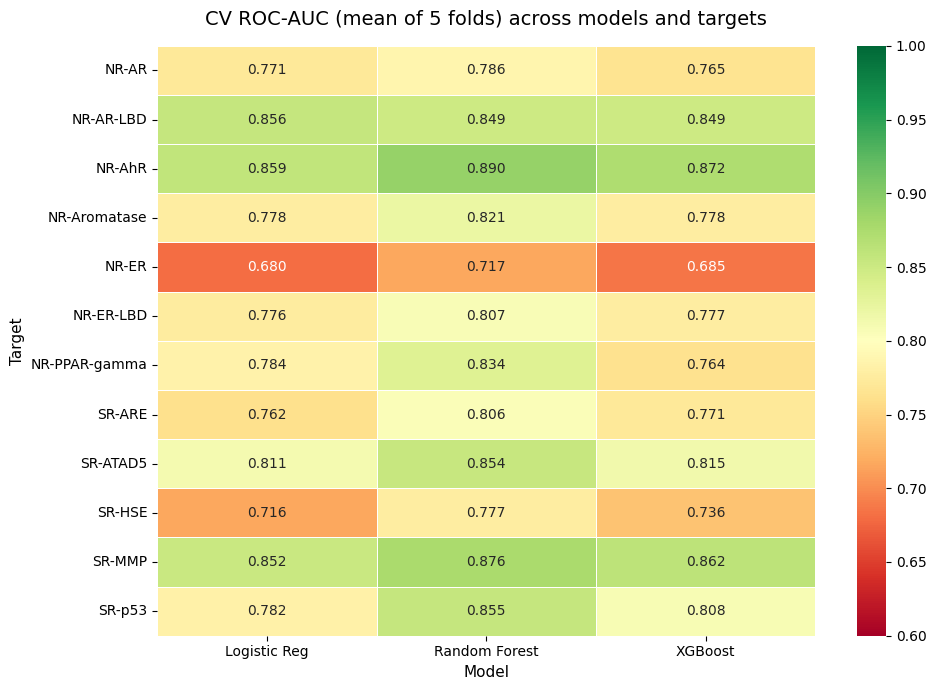

Saved!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_cv_pivot_roc = df_cv.pivot_table(index='Target', columns='Model', values='ROC-AUC mean')

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(df_cv_pivot_roc, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.6, vmax=1.0, linewidths=0.5, ax=ax)
ax.set_title("CV ROC-AUC (mean of 5 folds) across models and targets", fontsize=14, pad=15)
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Target", fontsize=11)
plt.tight_layout()
plt.savefig("../reports/figures/cv_roc_auc_heatmap.png", dpi=150)
plt.show()
print("Saved!")

## CV PR-AUC Heatmap (mean across 5 folds)

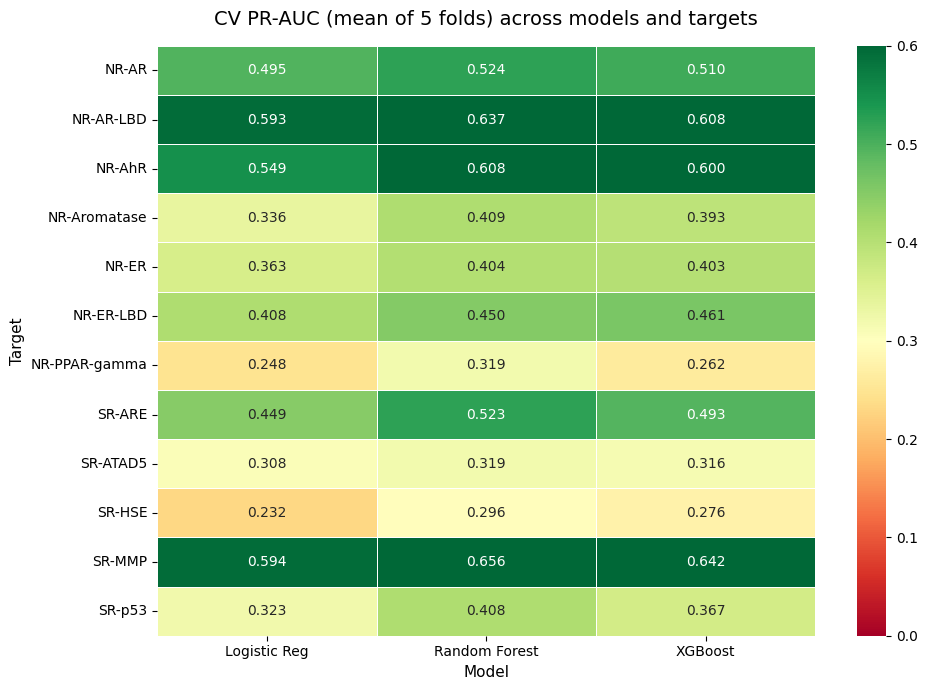

Saved!


In [ ]:
df_cv_pivot_pr = df_cv.pivot_table(index='Target', columns='Model', values='PR-AUC mean')

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(df_cv_pivot_pr, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.0, vmax=0.6, linewidths=0.5, ax=ax)
ax.set_title("CV PR-AUC (mean of 5 folds) across models and targets", fontsize=14, pad=15)
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Target", fontsize=11)
plt.tight_layout()
plt.savefig("../reports/figures/cv_pr_auc_heatmap.png", dpi=150)
plt.show()
print("Saved!")

## CV Stability Check (std across folds)

Low std = stable model. High std = score is sensitive to which molecules end up in the fold — worth flagging in the report.

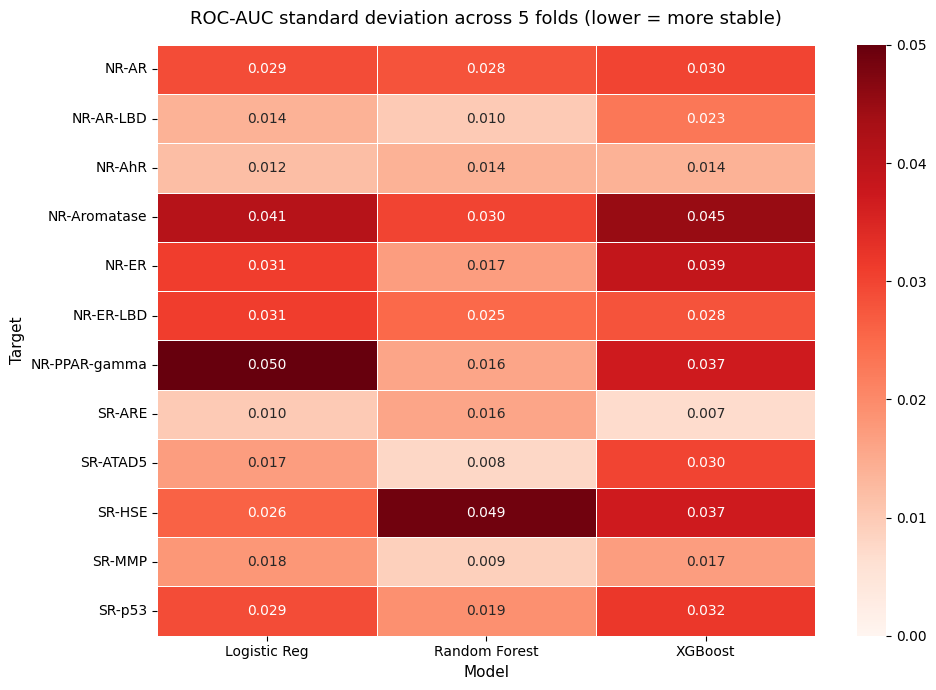

Saved!


In [ ]:
df_cv_pivot_std = df_cv.pivot_table(index='Target', columns='Model', values='ROC-AUC std')

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(df_cv_pivot_std, annot=True, fmt='.3f', cmap='Reds',
            vmin=0.0, vmax=0.05, linewidths=0.5, ax=ax)
ax.set_title("ROC-AUC standard deviation across 5 folds (lower = more stable)", fontsize=13, pad=15)
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Target", fontsize=11)
plt.tight_layout()
plt.savefig("../reports/figures/cv_stability_heatmap.png", dpi=150)
plt.show()
print("Saved!")

## Baseline Heatmaps (single split — for contrast with CV results only)

In [ ]:
df_results = pd.DataFrame(results)
df_pivot = df_results.pivot_table(index='Target', columns='Model', values='ROC-AUC')
df_pivot = df_pivot.round(3)
print(df_pivot)

Model          Logistic Reg  Random Forest  XGBoost
Target                                             
NR-AR                 0.735          0.741    0.714
NR-AR-LBD             0.799          0.794    0.790
NR-AhR                0.872          0.908    0.892
NR-Aromatase          0.840          0.871    0.814
NR-ER                 0.677          0.700    0.666
NR-ER-LBD             0.793          0.787    0.746
NR-PPAR-gamma         0.760          0.807    0.780
SR-ARE                0.770          0.823    0.787
SR-ATAD5              0.843          0.861    0.820
SR-HSE                0.721          0.799    0.718
SR-MMP                0.838          0.874    0.864
SR-p53                0.784          0.852    0.818


In [ ]:
df_results.to_csv("../reports/model_comparison.csv", index=False)
print("Results saved!")

Results saved!


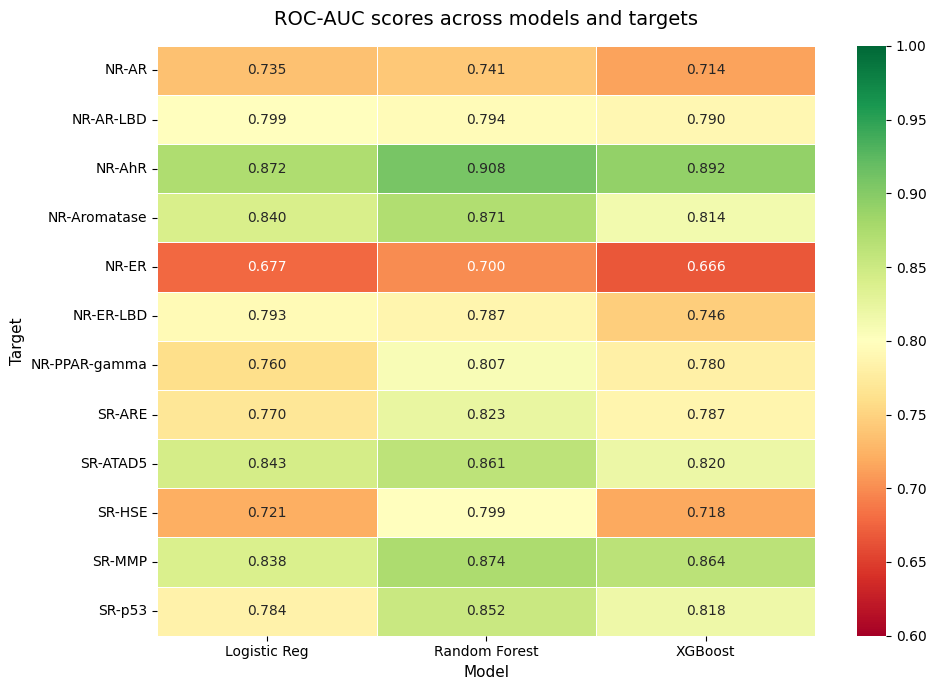

Saved!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(df_pivot, 
            annot=True, 
            fmt='.3f',
            cmap='RdYlGn',
            vmin=0.6, vmax=1.0,
            linewidths=0.5,
            ax=ax)

ax.set_title("ROC-AUC scores across models and targets", fontsize=14, pad=15)
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Target", fontsize=11)

plt.tight_layout()
plt.savefig("../reports/figures/roc_auc_heatmap.png", dpi=150)
plt.show()
print("Saved!")

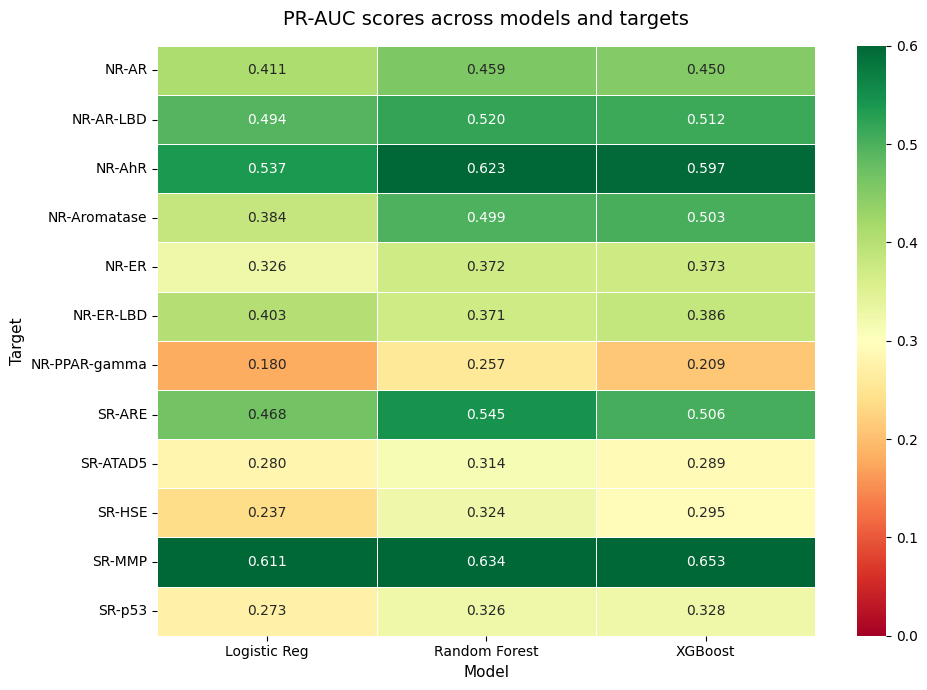

Saved!


In [ ]:
df_pivot_pr = df_results.pivot_table(index='Target', columns='Model', values='PR-AUC')
df_pivot_pr = df_pivot_pr.round(3)

fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(df_pivot_pr, 
            annot=True, 
            fmt='.3f',
            cmap='RdYlGn',
            vmin=0.0, vmax=0.6,
            linewidths=0.5,
            ax=ax)

ax.set_title("PR-AUC scores across models and targets", fontsize=14, pad=15)
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Target", fontsize=11)

plt.tight_layout()
plt.savefig("../reports/figures/pr_auc_heatmap.png", dpi=150)
plt.show()
print("Saved!")

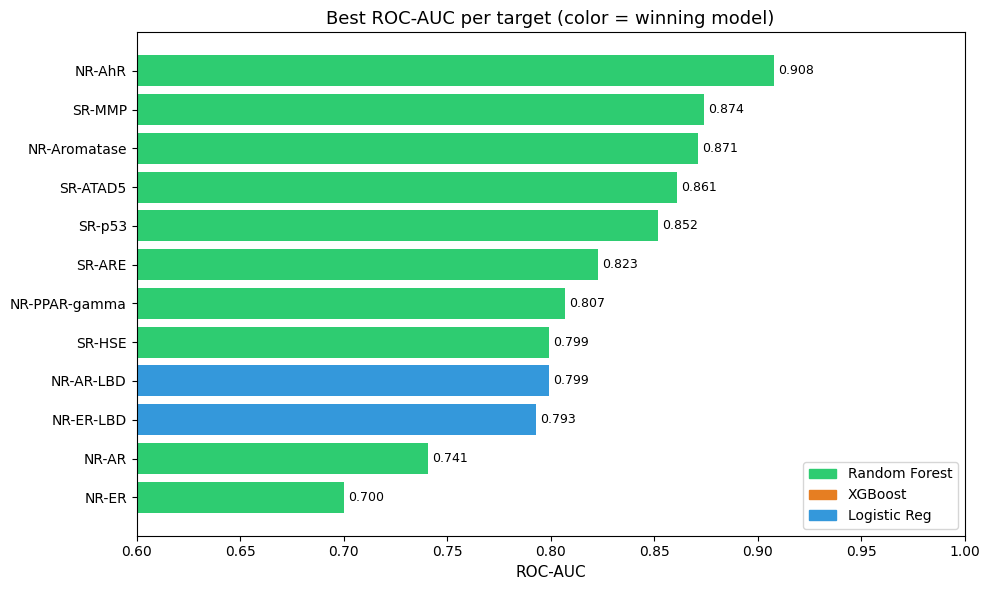

Saved!


In [ ]:
best = df_results.loc[df_results.groupby('Target')['ROC-AUC'].idxmax()]
best = best.sort_values('ROC-AUC', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ecc71' if m == 'Random Forest' else '#e67e22' if m == 'XGBoost' else '#3498db' 
          for m in best['Model']]

bars = ax.barh(best['Target'], best['ROC-AUC'], color=colors)

ax.set_xlim(0.6, 1.0)
ax.set_xlabel("ROC-AUC", fontsize=11)
ax.set_title("Best ROC-AUC per target (color = winning model)", fontsize=13)

from matplotlib.patches import Patch
legend = [Patch(color='#2ecc71', label='Random Forest'),
          Patch(color='#e67e22', label='XGBoost'),
          Patch(color='#3498db', label='Logistic Reg')]
ax.legend(handles=legend)

for bar, val in zip(bars, best['ROC-AUC']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig("../reports/figures/best_model_per_target.png", dpi=150)
plt.show()
print("Saved!")

## Hyperparameter Tuning — XGBoost (RandomizedSearchCV across all targets)

We use `RandomizedSearchCV` instead of `GridSearchCV` — it samples a fixed number of random combinations instead of every possible one, getting most of the benefit in a fraction of the time. This is the standard choice when tuning across many targets under time constraints.

In [ ]:
param_dist = {
    "n_estimators": randint(100, 400),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.29),
    "min_child_weight": randint(1, 10),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
}
print("Search space defined!")

In [ ]:
best_xgb_params = {}
tuned_xgb_scores = {}

for i, target in enumerate(targets):
    print(f"Tuning XGBoost on {target}...")
    mask = ~np.isnan(y[:, i])
    X_t = X[mask]
    y_t = y[mask, i].astype(int)
    neg, pos = (y_t == 0).sum(), (y_t == 1).sum()

    xgb_base = XGBClassifier(scale_pos_weight=neg/pos, eval_metric='auc', random_state=42, verbosity=0)

    search = RandomizedSearchCV(
        xgb_base, param_dist,
        n_iter=20,
        scoring='roc_auc',
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        random_state=42,
        n_jobs=-1,
    )
    search.fit(X_t, y_t)

    best_xgb_params[target] = search.best_params_
    tuned_xgb_scores[target] = search.best_score_
    print(f"  -> Best ROC-AUC: {search.best_score_:.3f}")

print("\nAll targets tuned!")

Tuning XGBoost on NR-AR...


KeyboardInterrupt: 

## Default vs Tuned — XGBoost Comparison Table

This is the before/after evidence: default hyperparameters vs RandomizedSearchCV-tuned, both evaluated with 5-fold CV.

In [ ]:
xgb_default_scores = df_cv[df_cv['Model'] == 'XGBoost'].set_index('Target')['ROC-AUC mean']

comparison_rows = []
for target in targets:
    default_score = xgb_default_scores[target]
    tuned_score = tuned_xgb_scores[target]
    comparison_rows.append({
        "Target": target,
        "XGB Default ROC-AUC": round(default_score, 3),
        "XGB Tuned ROC-AUC": round(tuned_score, 3),
        "Improvement": round(tuned_score - default_score, 3),
    })

df_xgb_compare = pd.DataFrame(comparison_rows).sort_values("Improvement", ascending=False)
print(df_xgb_compare)
df_xgb_compare.to_csv("../reports/xgb_default_vs_tuned.csv", index=False)
print("\nSaved!")

## Visualize Default vs Tuned Improvement

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

df_plot = df_xgb_compare.sort_values("Improvement")
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in df_plot['Improvement']]
ax.barh(df_plot['Target'], df_plot['Improvement'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel("ROC-AUC improvement (Tuned - Default)")
ax.set_title("XGBoost: gain from hyperparameter tuning, per target")

plt.tight_layout()
plt.savefig("../reports/figures/xgb_tuning_improvement.png", dpi=150)
plt.show()
print("Saved!")

## Hyperparameter Tuning — Random Forest (lighter pass)

Random Forest defaults were already close to optimal in our CV results, so we use a smaller search space and fewer iterations — just to confirm there's no easy gain left on the table.

In [ ]:
rf_param_dist = {
    "n_estimators": randint(150, 400),
    "max_depth": [None, 10, 20, 30],
    "min_samples_leaf": randint(1, 5),
    "max_features": ['sqrt', 'log2'],
}

best_rf_params = {}
tuned_rf_scores = {}

for i, target in enumerate(targets):
    print(f"Tuning Random Forest on {target}...")
    mask = ~np.isnan(y[:, i])
    X_t = X[mask]
    y_t = y[mask, i].astype(int)

    rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

    search = RandomizedSearchCV(
        rf_base, rf_param_dist,
        n_iter=12,
        scoring='roc_auc',
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        random_state=42,
        n_jobs=-1,
    )
    search.fit(X_t, y_t)

    best_rf_params[target] = search.best_params_
    tuned_rf_scores[target] = search.best_score_
    print(f"  -> Best ROC-AUC: {search.best_score_:.3f}")

print("\nAll targets tuned for RF!")

## Default vs Tuned — Random Forest Comparison Table

In [ ]:
rf_default_scores = df_cv[df_cv['Model'] == 'Random Forest'].set_index('Target')['ROC-AUC mean']

rf_comparison_rows = []
for target in targets:
    default_score = rf_default_scores[target]
    tuned_score = tuned_rf_scores[target]
    rf_comparison_rows.append({
        "Target": target,
        "RF Default ROC-AUC": round(default_score, 3),
        "RF Tuned ROC-AUC": round(tuned_score, 3),
        "Improvement": round(tuned_score - default_score, 3),
    })

df_rf_compare = pd.DataFrame(rf_comparison_rows).sort_values("Improvement", ascending=False)
print(df_rf_compare)
df_rf_compare.to_csv("../reports/rf_default_vs_tuned.csv", index=False)
print("\nSaved!")

## Final Rebuilt Comparison — Best Tuned Model per Target

This combines tuned XGBoost, tuned Random Forest, and the CV Logistic Regression baseline (not tuned, since it was never competitive) into one final results table — this is the table to use in your report going forward.

In [ ]:
lr_scores = df_cv[df_cv['Model'] == 'Logistic Reg'].set_index('Target')['ROC-AUC mean']

final_rows = []
for target in targets:
    final_rows.append({"Target": target, "Model": "Random Forest (tuned)", "ROC-AUC": round(tuned_rf_scores[target], 3)})
    final_rows.append({"Target": target, "Model": "XGBoost (tuned)", "ROC-AUC": round(tuned_xgb_scores[target], 3)})
    final_rows.append({"Target": target, "Model": "Logistic Reg (CV)", "ROC-AUC": round(lr_scores[target], 3)})

df_final = pd.DataFrame(final_rows)
df_final_pivot = df_final.pivot_table(index='Target', columns='Model', values='ROC-AUC')
print(df_final_pivot)
df_final.to_csv("../reports/final_tuned_comparison.csv", index=False)
print("\nSaved!")

## Final Heatmap — Tuned Models

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(df_final_pivot, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.6, vmax=1.0, linewidths=0.5, ax=ax)
ax.set_title("Final ROC-AUC — tuned models across targets", fontsize=14, pad=15)
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Target", fontsize=11)
plt.tight_layout()
plt.savefig("../reports/figures/final_tuned_heatmap.png", dpi=150)
plt.show()
print("Saved!")